## Explanation: The cell below imports all necessary libraries for data analysis and visualization. We using pandas for data manipulation, numpy for numerical operations, matplotlib and seaborn for plotting, and datetime for handling date operations 

In [37]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#Setting up visualization style 
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All libraries imported successfully!")

All libraries imported successfully!


## Load data set

In [38]:
df = pd.read_csv('retail_sales.csv')

In [39]:
df.head(10)

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East
5,1/2/2023,Electronics,722.775149,10.0,82.396149,West
6,1/2/2023,Clothing,788.996859,15.0,225.271072,West
7,1/2/2023,Home Goods,358.113803,3.0,128.198339,East
8,1/2/2023,Sports,819.923845,2.0,250.298077,East
9,1/2/2023,Books,1284.231946,7.0,363.436353,West


## Explanation: This cell provides basic information about the dataset including dimensions, column names, data types, and checks for missing values.

In [40]:
# Basic Data Information and Structure
print("=== DATASET BASIC INFORMATION ===")
print(f"Dataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn Names and Data Types:")
print(df.dtypes)

=== DATASET BASIC INFORMATION ===
Dataset Dimensions: 1825 rows × 6 columns

Column Names and Data Types:
Date         object
Category     object
Sales       float64
Quantity    float64
Profit      float64
Region       object
dtype: object


In [41]:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Summary:")
df.info()


Missing Values:
Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [42]:
# Data Type Conversion and Cleaning
print("=== DATA CLEANING AND TYPE CONVERSION ===")

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract additional time features
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['DayOfWeek'] = df['Date'].dt.day_name()
df['MonthName'] = df['Date'].dt.month_name()

# Ensure numeric columns are properly formatted
numeric_columns = ['Sales', 'Quantity', 'Profit']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")

=== DATA CLEANING AND TYPE CONVERSION ===
Data types after conversion:
Date         datetime64[ns]
Category             object
Sales               float64
Quantity            float64
Profit              float64
Region               object
Month                 int32
Quarter               int32
DayOfWeek            object
MonthName            object
dtype: object

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


## Explanation: This cell provides comprehensive statistical sum, dispersion, and aggregations   by category and region.

In [43]:
# Basic Statistical Summary
print("=== STATISTICAL SUMMARY ===")
print("Descriptive Statistics for Numerical Columns:")
print(df[['Sales', 'Quantity', 'Profit']].describe())

=== STATISTICAL SUMMARY ===
Descriptive Statistics for Numerical Columns:
             Sales     Quantity       Profit
count  1823.000000  1820.000000  1825.000000
mean    980.482677    10.053846   248.696130
std     336.756618     5.515370   118.159627
min       0.000000     0.000000     0.000000
25%     784.071354     5.000000   156.916498
50%     997.725134    10.000000   229.344557
75%    1208.512721    15.000000   324.867847
max    1888.932537    19.000000   703.228418


In [44]:
print("\nCategory-wise Summary:")
category_summary = df.groupby('Category').agg({
    'Sales': ['count', 'sum', 'mean', 'std'],
    'Profit': ['sum', 'mean'],
    'Quantity': ['sum', 'mean']
}).round(2)
print(category_summary)


Category-wise Summary:
            Sales                                Profit         Quantity  \
            count        sum     mean     std       sum    mean      sum   
Category                                                                   
Books         364  370971.87  1019.15  336.39  92304.45  253.58   3737.0   
Clothing      365  350981.82   961.59  337.49  90082.12  246.80   3641.0   
Electronics   360  364090.41  1011.36  344.25  90439.70  250.53   3595.0   
Home Goods    364  347493.83   954.65  332.39  87447.82  240.24   3777.0   
NaN?            1     828.59   828.59     NaN     88.59   88.59     12.0   
Nan             1     823.19   823.19     NaN    253.43  253.43      4.0   
Null            1    1106.85  1106.85     NaN    381.78  381.78     11.0   
Sports        363  346685.06   955.06  331.20  92065.22  252.93   3492.0   

                    
              mean  
Category            
Books        10.27  
Clothing      9.98  
Electronics   9.96  
Home Goods   

In [45]:
print("\nRegion-wise Summary:")
region_summary = df.groupby('Region').agg({
    'Sales': ['sum', 'mean'],
    'Profit': ['sum', 'mean']
}).round(2)
print(region_summary)


Region-wise Summary:
            Sales              Profit        
              sum     mean        sum    mean
Region                                       
East    393441.61   991.04   98973.62  248.68
Nan       1716.71  1716.71     545.62  545.62
North   448295.03   976.68  112126.47  243.75
South   469471.28   969.98  118036.97  243.88
West    470514.37   986.40  122517.78  256.85


## Explanation: This cell analyzes monthly sales trends by aggregating data by month and line chart showing sales and profit patterns troughout te year.

In [46]:
# Cell 6: Monthly Sales Trend Analysis
print("=== MONTHLY SALES TREND ANALYSIS ===")

# Calculate monthly sales
monthly_sales = df.groupby(['Month', 'MonthName']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).reset_index()

monthly_sales = monthly_sales.sort_values('Month')
print("Monthly Sales Summary:")
print(monthly_sales)

=== MONTHLY SALES TREND ANALYSIS ===
Monthly Sales Summary:
    Month  MonthName          Sales        Profit  Quantity
0       1    January  147068.619477  39711.436221    1486.0
1       2   February  132215.411776  34353.123612    1517.0
2       3      March  145321.200626  38584.599285    1447.0
3       4      April  138160.991209  37895.203187    1446.0
4       5        May  150774.977103  40527.689566    1603.0
5       6       June  152605.749860  39042.686605    1570.0
6       7       July  162111.115687  40208.956109    1536.0
7       8     August  148020.452251  34675.627875    1489.0
8       9  September  153094.700793  37796.761379    1598.0
9      10    October  151272.280840  36019.384158    1569.0
10     11   November  146795.613628  36344.048332    1461.0
11     12   December  159978.807192  38710.920857    1576.0


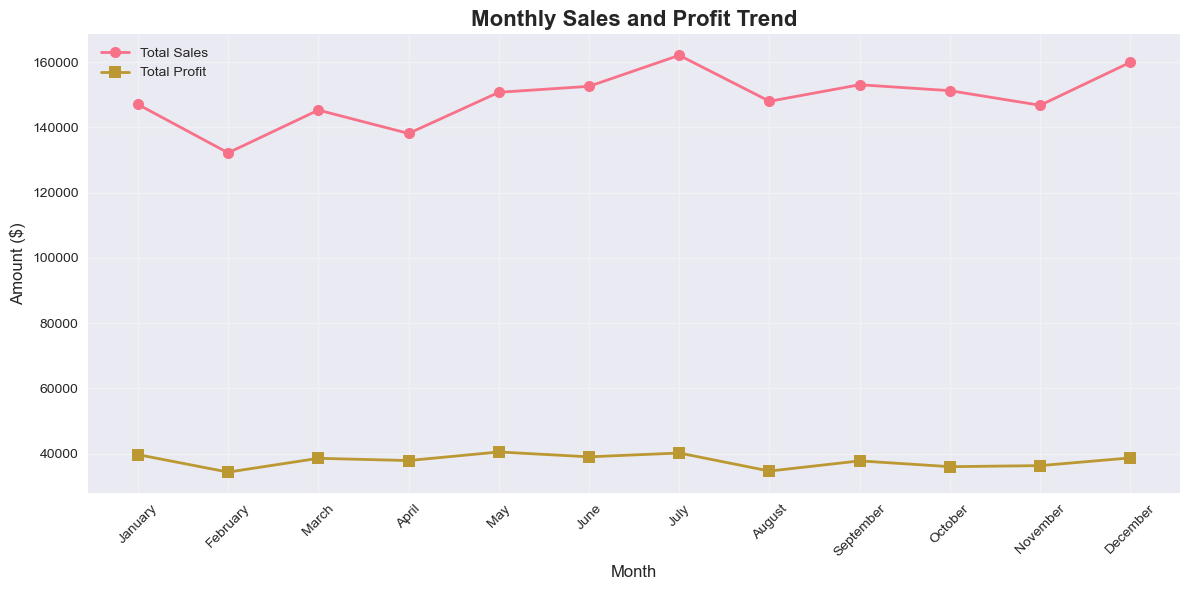

In [47]:
# Visualization 1: Monthly Sales Trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['MonthName'], monthly_sales['Sales'],
         marker='o', linewidth=2, markersize=8, label='Total Sales')
plt.plot(monthly_sales['MonthName'], monthly_sales['Profit'],
         marker='s', linewidth=2, markersize=8, label='Total Profit')
plt.title('Monthly Sales and Profit Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Explanation: This cell analyzes performance across different product categories, sorts them by sales, annd creates a bar chart visualizing total sales by category.

In [48]:
# Cell 7: Category Performance Analysis
print("=== CATEGORY PERFORMANCE ANALYSIS ===")

category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum'
}).sort_values('Sales', ascending=False)

print("Category Performance (Sorted by Sales):")
print(category_performance)

=== CATEGORY PERFORMANCE ANALYSIS ===
Category Performance (Sorted by Sales):
                     Sales        Profit  Quantity
Category                                          
Books        370971.872558  92304.452141    3737.0
Electronics  364090.406288  90439.697795    3595.0
Clothing     350981.822773  90082.119920    3641.0
Home Goods   347493.827088  87447.820056    3777.0
Sports       346685.063298  92065.220851    3492.0
Null           1106.847949    381.784578      11.0
NaN?            828.585950     88.591355      12.0
Nan             823.190573    253.433301       4.0


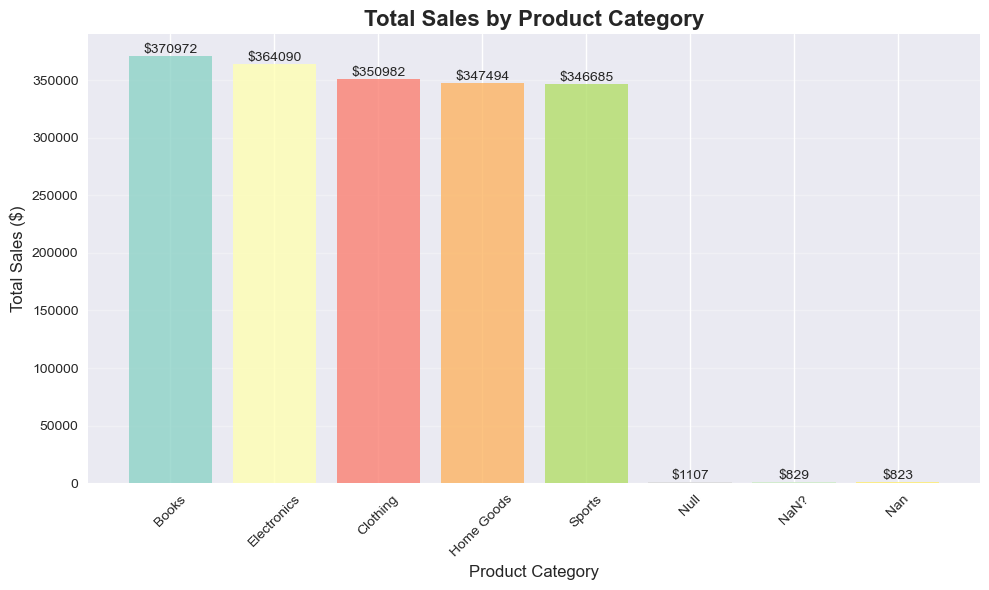

In [49]:
# Visualization 2: Top Categories by Sales
plt.figure(figsize=(10, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(category_performance)))
bars = plt.bar(category_performance.index, category_performance['Sales'],
               color=colors, alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.0f}', ha='center', va='bottom')

plt.title('Total Sales by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Explanation: This cell analyzes sales performance across different regions and create a pie cleaning showing the distribution of sales by region.

In [50]:
# Cell 8: Regional Performance Analysis
print("=== REGIONAL PERFORMANCE ANALYSIS ===")

regional_performance = df.groupby('Region').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean']
}).round(2)

print("Regional Performance:")
print(regional_performance)

=== REGIONAL PERFORMANCE ANALYSIS ===
Regional Performance:
            Sales                    Profit        
              sum     mean count        sum    mean
Region                                             
East    393441.61   991.04   397   98973.62  248.68
Nan       1716.71  1716.71     1     545.62  545.62
North   448295.03   976.68   459  112126.47  243.75
South   469471.28   969.98   484  118036.97  243.88
West    470514.37   986.40   477  122517.78  256.85


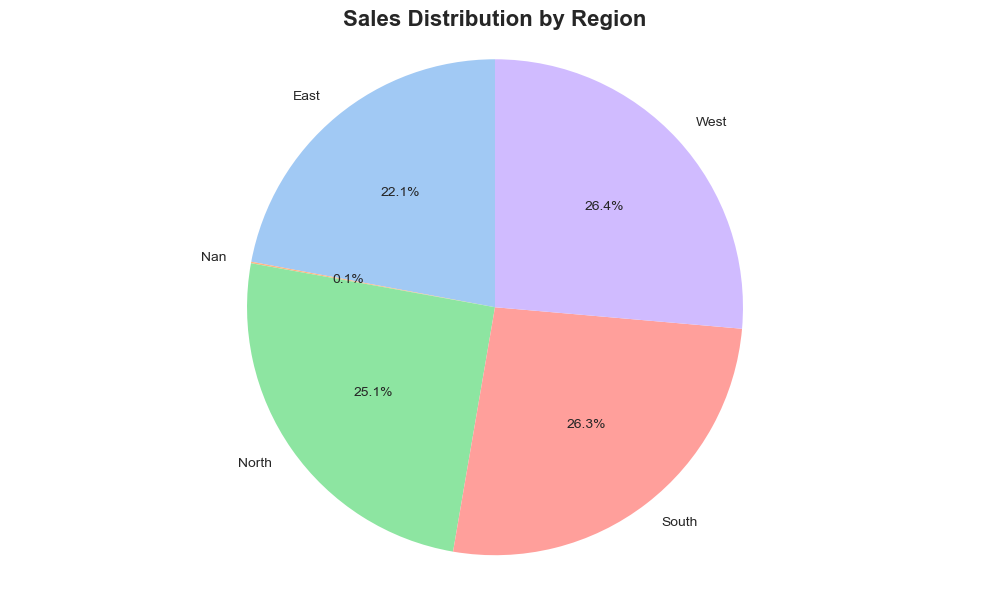

In [51]:
# Visualization 3: Regional Sales Distribution
plt.figure(figsize=(10, 6))
regional_data = df.groupby('Region')['Sales'].sum()
plt.pie(regional_data, labels=regional_data.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette("pastel"))
plt.title('Sales Distribution by Region', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Explanation: This cell analyzes sales by day of the week and creates a line chart showing how sales and profit vary throughout the week.

=== DAY OF WEEK ANALYSIS ===
Average Performance by Day of Week:
             Sales  Profit  Quantity
DayOfWeek                           
Monday      981.77  253.32     10.24
Tuesday     981.92  244.18     10.31
Wednesday   965.23  237.57     10.18
Thursday    966.83  237.62      9.78
Friday     1014.31  259.80     10.00
Saturday    972.20  253.32      9.64
Sunday      981.11  254.94     10.22


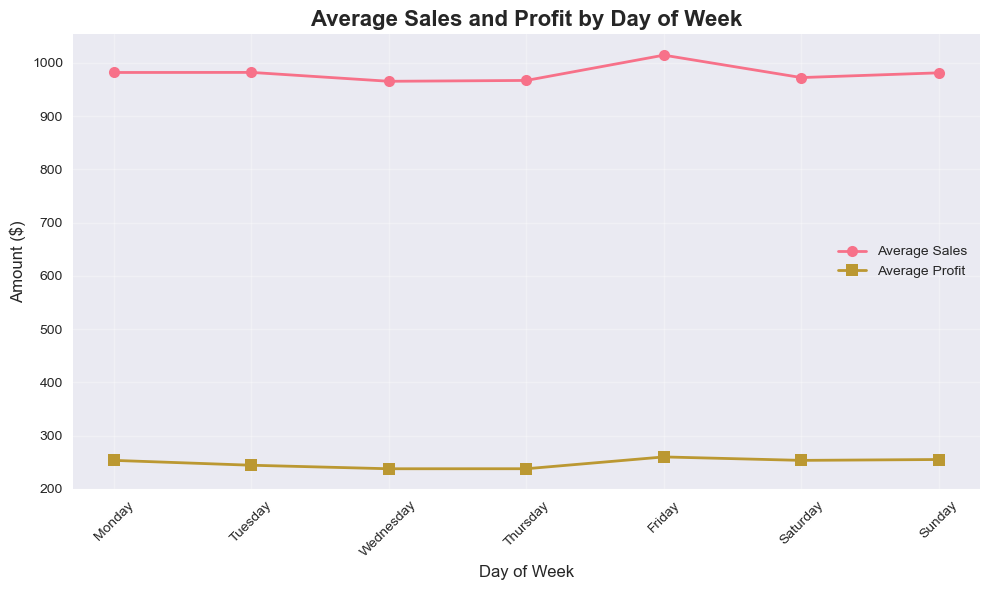

In [52]:
#Day of Week Analysis
print("=== DAY OF WEEK ANALYSIS ===")

# Define proper order for days
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=day_order, ordered=True)

daily_performance = df.groupby('DayOfWeek').agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Quantity': 'mean'
}).round(2)

print("Average Performance by Day of Week:")
print(daily_performance)

# Visualization 4: Daily Sales Pattern
plt.figure(figsize=(10, 6))
plt.plot(daily_performance.index, daily_performance['Sales'],
         marker='o', linewidth=2, markersize=8, label='Average Sales')
plt.plot(daily_performance.index, daily_performance['Profit'],
         marker='s', linewidth=2, markersize=8, label='Average Profit')
plt.title('Average Sales and Profit by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Explanation: This cell calculates correlations between numerical variables and creates a heatmap to visualize relationships between sales, quantity, profit, and time.  

=== CORRELATION ANALYSIS ===
Correlation Matrix:
             Sales  Quantity    Profit     Month
Sales     1.000000  0.056824  0.525041  0.065291
Quantity  0.056824  1.000000  0.027875  0.003127
Profit    0.525041  0.027875  1.000000 -0.034678
Month     0.065291  0.003127 -0.034678  1.000000


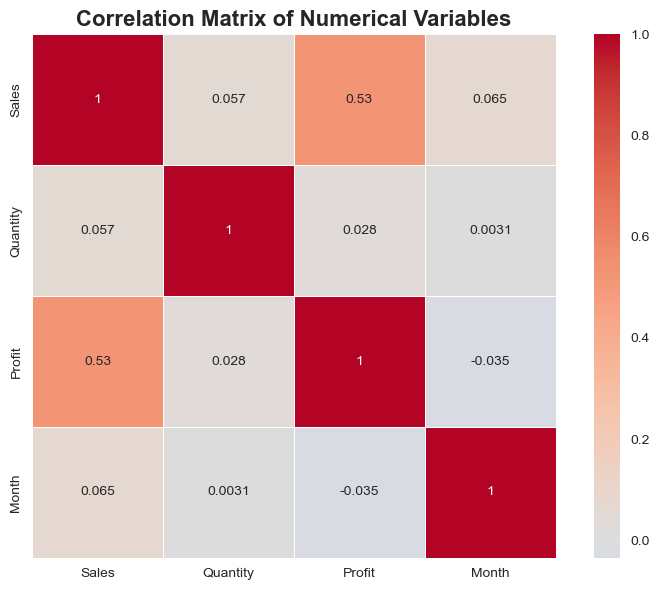

In [53]:
# Correlation Analysis
print("=== CORRELATION ANALYSIS ===")

# Select numerical columns for correlation
numerical_df = df[['Sales', 'Quantity', 'Profit', 'Month']]
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Explanation: This cell creates a comprehensive 4-chart dashboard that summarizes a key insight from the previous analyses in a single view system.

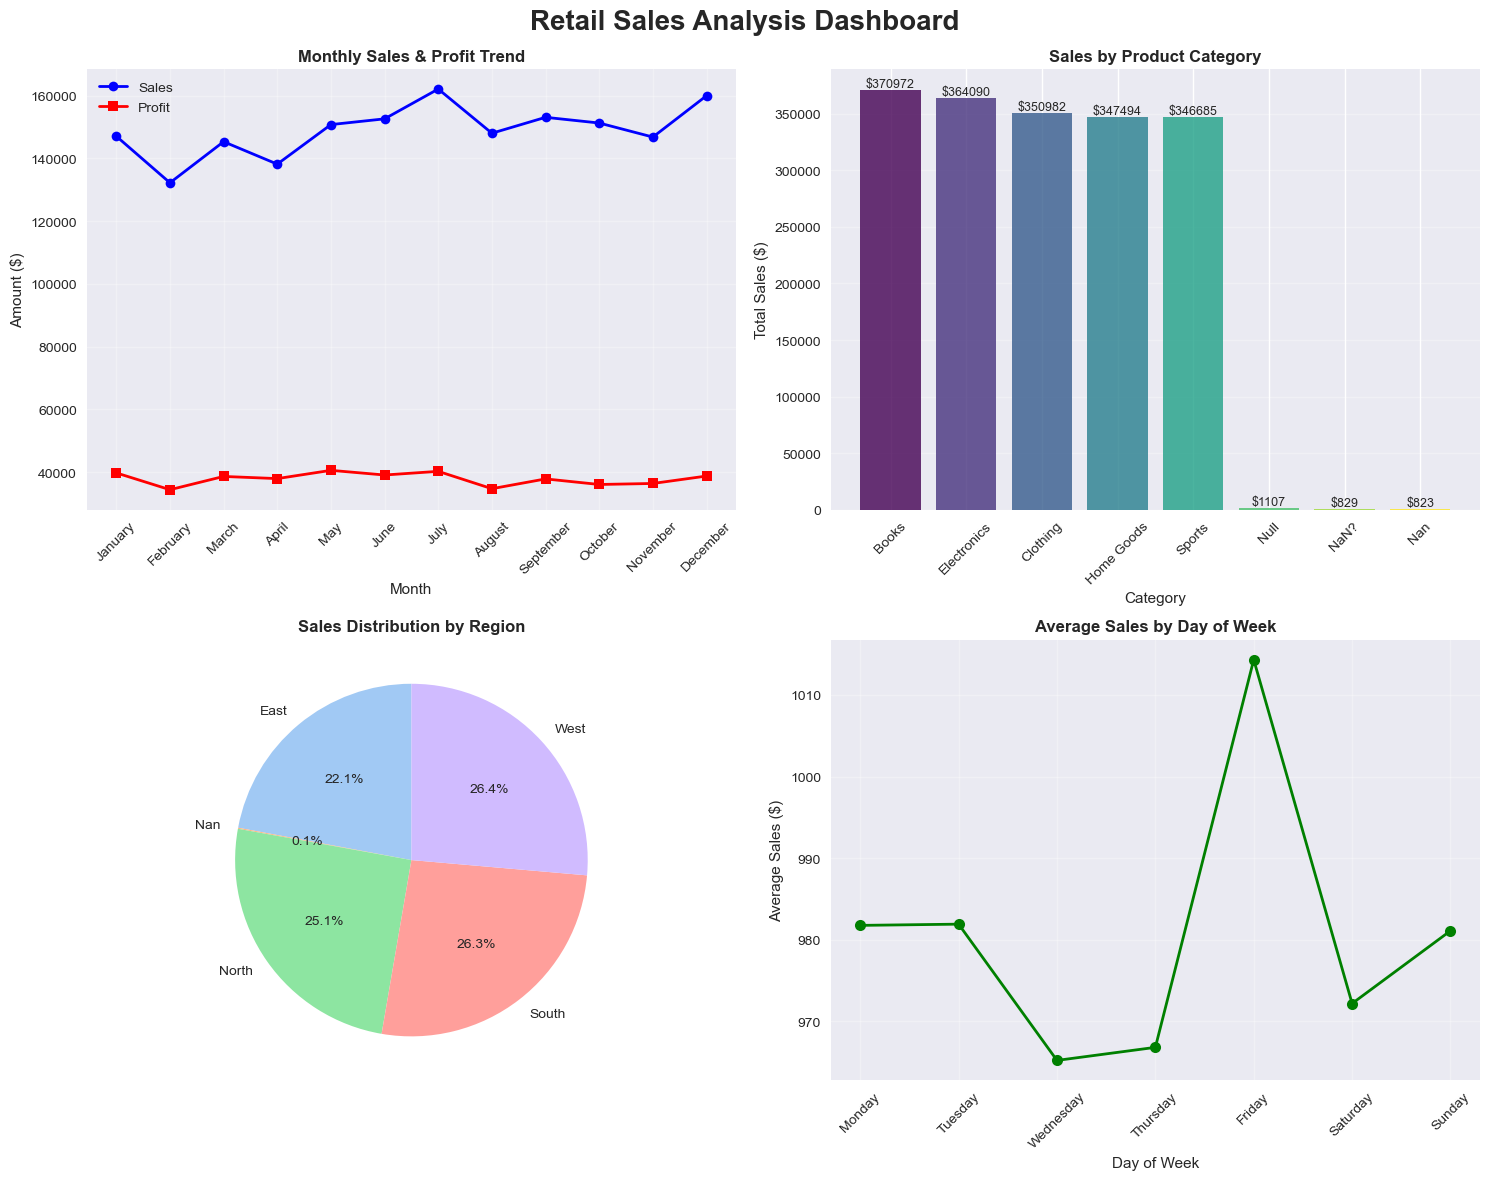

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
df = pd.read_csv("retail_sales.csv")

# Date convert karo
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.month_name()
df['DayOfWeek'] = df['Date'].dt.day_name()

# Monthly sales
monthly_sales = df.groupby(['Month', 'MonthName']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index().sort_values('Month')

# Category performance
category_performance = df.groupby('Category').agg({
    'Sales': 'sum'
}).sort_values('Sales', ascending=False)

# Region data
regional_data = df.groupby('Region')['Sales'].sum()

# Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=day_order, ordered=True)
daily_performance = df.groupby('DayOfWeek').agg({'Sales': 'mean'}).round(2)

# ===== 4-CHART DASHBOARD =====
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Retail Sales Analysis Dashboard', fontsize=20, fontweight='bold')

# Chart 1: Monthly Sales & Profit Trend (Top-Left)
axes[0,0].plot(monthly_sales['MonthName'], monthly_sales['Sales'],
               marker='o', linewidth=2, color='blue', label='Sales')
axes[0,0].plot(monthly_sales['MonthName'], monthly_sales['Profit'],
               marker='s', linewidth=2, color='red', label='Profit')
axes[0,0].set_title('Monthly Sales & Profit Trend', fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Amount ($)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2: Sales by Product Category (Top-Right)
colors = plt.cm.viridis(np.linspace(0, 1, len(category_performance)))
bars = axes[0,1].bar(category_performance.index, category_performance['Sales'],
                     color=colors, alpha=0.8)
for bar in bars:
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height,
                   f'${height:.0f}', ha='center', va='bottom', fontsize=9)
axes[0,1].set_title('Sales by Product Category', fontweight='bold')
axes[0,1].set_xlabel('Category')
axes[0,1].set_ylabel('Total Sales ($)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)

# Chart 3: Sales Distribution by Region (Bottom-Left)
axes[2//2, 0].pie(regional_data, labels=regional_data.index,
                  autopct='%1.1f%%', startangle=90,
                  colors=sns.color_palette("pastel"))
axes[1,0].set_title('Sales Distribution by Region', fontweight='bold')

# Chart 4: Average Sales by Day of Week (Bottom-Right)
axes[1,1].plot(daily_performance.index, daily_performance['Sales'],
               marker='o', linewidth=2, color='green', markersize=8)
axes[1,1].set_title('Average Sales by Day of Week', fontweight='bold')
axes[1,1].set_xlabel('Day of Week')
axes[1,1].set_ylabel('Average Sales ($)')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

In [55]:
# Category performance with Profit
category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).sort_values('Sales', ascending=False)

#Key Insights and Business Recommendations
print("=== KEY INSIGHTS AND RECOMMENDATIONS ===")

print("\n📊 KEY FINDINGS:")
print("1. Top Performing Category:", category_performance.index[0])
print("2. Best Performing Region:", regional_data.idxmax())
print("3. Highest Sales Month:", monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'MonthName'])
print("4. Best Day of Week:", daily_performance['Sales'].idxmax())
print("5. Total Annual Sales: ${:,.2f}".format(df['Sales'].sum()))
print("6. Total Annual Profit: ${:,.2f}".format(df['Profit'].sum()))

print("\n💡 BUSINESS RECOMMENDATIONS:")
print("1. Focus marketing efforts on", category_performance.index[0], "category")
print("2. Investigate performance in lower-performing regions")
print("3. Plan promotions around", daily_performance['Sales'].idxmax(), "to maximize sales")
print("4. Allocate inventory based on monthly trend patterns")
print("5. Monitor correlation between quantity and profit for pricing strategy")

print("\n📝 PROFITABILITY ANALYSIS:")
profit_margin = (df['Profit'].sum() / df['Sales'].sum()) * 100
print(f"Overall Profit Margin: {profit_margin:.2f}%")

# Category profit margins
category_margins = (category_performance['Profit'] / category_performance['Sales']) * 100
print("\nProfit Margins by Category:")
for category, margin in category_margins.items():
    print(f"  {category}: {margin:.2f}%")

=== KEY INSIGHTS AND RECOMMENDATIONS ===

📊 KEY FINDINGS:
1. Top Performing Category: Books
2. Best Performing Region: West
3. Highest Sales Month: July
4. Best Day of Week: Friday
5. Total Annual Sales: $1,787,419.92
6. Total Annual Profit: $453,870.44

💡 BUSINESS RECOMMENDATIONS:
1. Focus marketing efforts on Books category
2. Investigate performance in lower-performing regions
3. Plan promotions around Friday to maximize sales
4. Allocate inventory based on monthly trend patterns
5. Monitor correlation between quantity and profit for pricing strategy

📝 PROFITABILITY ANALYSIS:
Overall Profit Margin: 25.39%

Profit Margins by Category:
  Books: 24.88%
  Electronics: 24.84%
  Clothing: 25.67%
  Home Goods: 25.17%
  Sports: 26.56%
  Null: 34.49%
  NaN?: 10.69%
  Nan: 30.79%
